# Bayesian inference on function space
+ This notebook focuses on the Bayesian inference on function space
+ There are several methods to implement the bayesian inference
+ We first consider about functional SGLD

# Functional Variational Inference
+ Objective function is as follows:
$$
L(m,S) = -E_q[\log p(Y_D | f(X_D; w))] + \max_{x_M \in \chi_M} KL(q(f^{X_M})||p_0(f^{X_M})),
$$
where $p_0$ is prior distribution, $q$ is the obtained approximated distribution,
$p(Y_D | f(X_D;w))$ is the likelihood, $\chi_M$ is a collections of $M$ samples whose size is $S$.
+ $E_q$ is replaced by reparameterization trick, and $q$ and $p_0$ is replaced by $M$-dimensional gaussian distribution.

## Simple case
+ We consider the following function:
$$
f(x;w) = a \tanh (bx), w=(a,b)
$$

In [1]:
%matplotlib inline

In [2]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
from torch.autograd import functional as F

In [53]:
# define nn.Module of f(x,w) = a tanh(b x)
# where a and b are parameters of the model
class SimpleFunc(nn.Module):
    a: nn.Parameter
    b: nn.Parameter

    def __init__(self, a: float | None = None, b: float | None = None):
        super(SimpleFunc, self).__init__()
        _a = torch.tensor([a]) if a is not None else torch.randn(1)
        _b = torch.tensor([b]) if b is not None else torch.randn(1)

        self.a = nn.Parameter(_a.clone().detach().requires_grad_(True))
        self.b = nn.Parameter(_b.clone().detach().requires_grad_(True))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * torch.tanh(self.b * x)

    @classmethod 
    def forward_with_params(cls, x: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        return params[0] * torch.tanh(params[1] * x)

    def jacobian(self, x: torch.Tensor) -> torch.Tensor:
        """Calculate the Jacobian of forward with respect to parameters using torch.autograd.functional.jacobian.
        
        Args:
            x: Input tensor of shape (n,)
            
        Returns:
            Jacobian tensor of shape (n, num_parameters) where each column
            represents the derivative with respect to one parameter
        """

        def _forward_with_params(params):
            return SimpleFunc.forward_with_params(x, params)
        
        #def forward_with_params(params):
        #    # Create a new module with the given parameters
        #    new_module = type(self)()
        #    param_idx = 0
        #    for param in new_module.parameters():
        #        param_size = param.numel()
        #        param.data = params[param_idx:param_idx + param_size].view(param.shape)
        #        param_idx += param_size
        #    print(new_module.forward(x))
        #    return new_module.forward(x)
        
        ## Get all parameters as a flat tensor
        #params = torch.cat([p.flatten() for p in self.parameters()])
        # Calculate Jacobian
        return F.jacobian(_forward_with_params, torch.tensor([self.a, self.b]))



In [50]:
true_a = 1.0
true_b = 1.0

In [54]:
test_simple_func = SimpleFunc(true_a, true_b)

In [55]:
torch.tensor([true_a, true_b])

tensor([1., 1.])

In [44]:
SimpleFunc.forward_with_params(X, torch.tensor([true_a, true_b]))

tensor([ 0.9156, -0.7858, -0.4978,  0.1978, -0.8594, -0.5991,  0.1119, -0.5153,
         0.4014,  0.6063])

In [ ]:
test_simple_func.forward(X)

tensor([ 0.9156, -0.7858, -0.4978,  0.1978, -0.8594, -0.5991,  0.1119, -0.5153,
         0.4014,  0.6063], grad_fn=<MulBackward0>)

In [63]:
n = 10
X = torch.randn(n)
y = true_a * torch.tanh(true_b * X) + torch.randn(n)

In [79]:
test_simple_func = SimpleFunc()

In [80]:
test_simple_func.a.grad, test_simple_func.b.grad

(None, None)

In [81]:
loss = ((y - test_simple_func.forward(X))**2).sum()

In [82]:
# calculate backward
loss.backward()

In [85]:
test_simple_func.a

Parameter containing:
tensor([-1.2640], requires_grad=True)

In [83]:
test_simple_func.a.grad, test_simple_func.b.grad

(tensor([-14.0775]), tensor([3.7026]))

In [61]:
test_simple_func.forward(X)

tensor([ 0.4102, -0.2858, -0.1497,  0.0552, -0.3443, -0.1888,  0.0310, -0.1561,
         0.1168,  0.1919], grad_fn=<MulBackward0>)

In [59]:
test_simple_func.jacobian(X)

tensor([[ 0.3678,  1.5056],
        [-0.2563, -1.1049],
        [-0.1343, -0.5984],
        [ 0.0495,  0.2230],
        [-0.3087, -1.3026],
        [-0.1693, -0.7493],
        [ 0.0278,  0.1253],
        [-0.1400, -0.6231],
        [ 0.1048,  0.4692],
        [ 0.1721,  0.7609]])

In [45]:
def jacob_test(params: torch.Tensor) -> torch.Tensor:
    return SimpleFunc.forward_with_params(X, params)

In [48]:
F.jacobian(jacob_test, torch.tensor([test_simple_func.a, test_simple_func.b]))

tensor([[ 0.9156,  0.2523],
        [-0.7858, -0.4056],
        [-0.4978, -0.4110],
        [ 0.1978,  0.1926],
        [-0.8594, -0.3375],
        [-0.5991, -0.4435],
        [ 0.1119,  0.1110],
        [-0.5153, -0.4186],
        [ 0.4014,  0.3568],
        [ 0.6063,  0.4446]])

In [46]:
F.jacobian(jacob_test, torch.tensor([true_a, true_b]))

tensor([[ 0.9156,  0.2523],
        [-0.7858, -0.4056],
        [-0.4978, -0.4110],
        [ 0.1978,  0.1926],
        [-0.8594, -0.3375],
        [-0.5991, -0.4435],
        [ 0.1119,  0.1110],
        [-0.5153, -0.4186],
        [ 0.4014,  0.3568],
        [ 0.6063,  0.4446]])

In [32]:
def test_forward(params):
    return params[0] * torch.tanh(params[1] * X)

In [56]:
test_simple_func.jacobian(X)

tensor([[ 0.9156,  0.2523],
        [-0.7858, -0.4056],
        [-0.4978, -0.4110],
        [ 0.1978,  0.1926],
        [-0.8594, -0.3375],
        [-0.5991, -0.4435],
        [ 0.1119,  0.1110],
        [-0.5153, -0.4186],
        [ 0.4014,  0.3568],
        [ 0.6063,  0.4446]])

<module 'torch.autograd.functional' from 'c:\\Users\\user\\anaconda3\\envs\\study\\Lib\\site-packages\\torch\\autograd\\functional.py'>

In [ ]:
F.jacobian()

In [4]:
def true_func(param: torch.Tensor) -> torch.Tensor:
    return param[0] * torch.tanh(param[1] * 3)

In [5]:
test = torch.Tensor([1,2])

In [6]:
F.jacobian(true_func, test)

tensor([9.9999e-01, 7.3671e-05])

In [7]:
data_seed = 20250514
n = 100

In [12]:
true_a=0.0
true_b=0.0

In [5]:
np.random.seed(data_seed)
# train_x = np.random.normal(size=n)
train_x = np.random.uniform(low=-10, high=10, size=n)
true_func = true_a * np.tanh(true_b * train_x)
train_y = true_func + 1.0 * np.random.normal(size=n)

In [19]:
test_simple_func = SimpleFunc(true_a, true_b)

In [11]:
%debug

> c:\users\user\appdata\local\temp\ipykernel_2460\3010342884.py(12)__init__()

tensor([0])
torch.int64


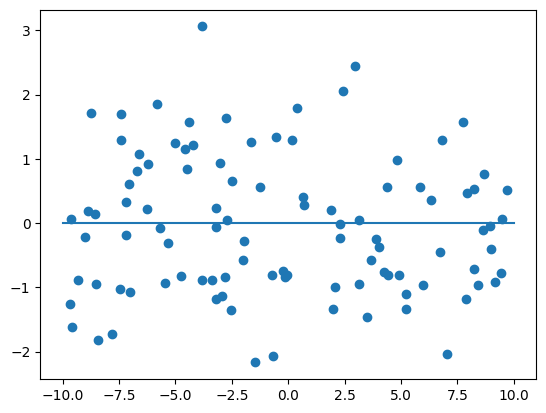

In [6]:
plot_x = np.linspace(-10, 10, num=1000)
plt.plot(plot_x, true_a * np.tanh(true_b * plot_x))
plt.scatter(train_x, train_y)
plt.show()

# Functional SGLD
+ The update rule is simple as follows:
+ Assuming that the form of the infered function is fixed as $f(x; w)$
$$
w_{t + 1} = w_t - \epsilon_t \frac{d}{dw} \{- \log p(y_D | x_D, w_t) + I_0(f^X_M) \} + \sqrt{2\epsilon_t} \eta_t,
$$
+ where $I_0$ is OM functional, which is interpretted as negative log prior
+ $f^X_M$ is $(f(x_1;w), f(x_2; w), \cdots, f(x_M;w))$
+ $\epsilon_t$ is postive value, which decays to 0
+ $\eta_t ~ N(0, I_k)$, where $k$ is dimension of the parameters $w$

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_seed = 20250514
n = 100

In [4]:
true_a=0
true_b=0

In [5]:
np.random.seed(data_seed)
# train_x = np.random.normal(size=n)
train_x = np.random.uniform(low=-10, high=10, size=n)
true_func = true_a * np.tanh(true_b * train_x)
train_y = true_func + 1.0 * np.random.normal(size=n)

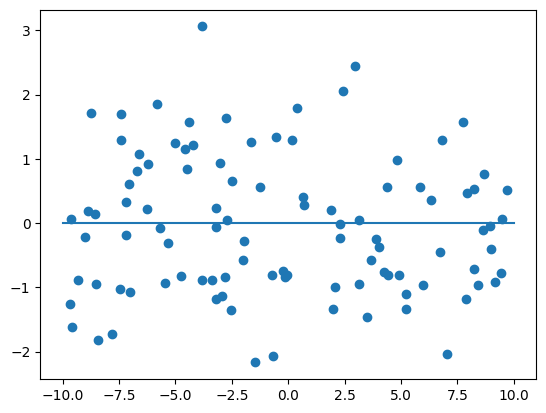

In [6]:
plot_x = np.linspace(-10, 10, num=1000)
plt.plot(plot_x, true_a * np.tanh(true_b * plot_x))
plt.scatter(train_x, train_y)
plt.show()

## train

In [7]:
ln_seed = 20240515

In [8]:
# assume the first element is a, the second is b
dim_param = 2

In [9]:
total_M = 100
chosen_M = 20

eval_x = np.random.uniform(low = -10, high = 10, size = total_M)

In [10]:
eps_0 = 0.001
decay_factor = 0.9
decay_cycle = 1000

In [11]:
burnin = 5000
n_post_samples = 500
sample_cycle = 100

In [12]:
def rbf_kernel(x: np.ndarray, beta:float=1, weight:float=1) -> np.ndarray:
    """ calc rbf kernel with the following form:
    K_ij = weight * exp(-beta * |x_i - x_j|^2)
    """
    n_dim = len(eval_x.shape)
    if n_dim == 1:
        return weight*np.exp(-beta*(x[:,np.newaxis] - x[np.newaxis,:])**2)
    elif n_dim == 2:
        return weight*np.exp(-beta*((x[:,np.newaxis,:] - x[np.newaxis,:,:])**2).sum(axis=2))
    else:
        raise ValueError(f"Currently n_dim > 3 is not supported, n_dim={n_dim}")

In [13]:
def calc_diff_of_param(param_a: float, param_b: float, x: np.ndarray) -> np.ndarray:
    """ calc diff at x
    """
    return np.array([np.tanh(param_b*x), param_a*x/np.cosh(param_b*x)**2]).T

In [14]:
def forward(param_a: float, param_b: float, x: np.ndarray) -> np.ndarray:
    return param_a * np.tanh(param_b * x)

In [15]:
def fsgld_sample(
    param: np.ndarray,
    y: np.ndarray,
    x: np.ndarray,
    eval_x: np.ndarray,
    kernel_xx: np.ndarray,
    eps_t: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """ calc for the next step of SGLD on function space
    param: tuple of a and b
    """
    param_a, param_b = param
    dw_logp = (y - forward(param_a, param_b, x)) @ calc_diff_of_param(param_a, param_b, x)
    dw_I0 = -forward(param_a, param_b, eval_x) @ kernel_xx @ calc_diff_of_param(param_a, param_b, eval_x)
    dU_t = dw_logp + dw_I0
    est_param = param + eps_t * dU_t + np.sqrt(2 * eps_t) * np.random.normal(size=dim_param)

    return est_param, dU_t, dw_logp

In [16]:
np.random.seed(ln_seed)
est_param = np.random.normal(size=dim_param)

eps_t = eps_0

history_param = []
history_logp = []
history_param.append(est_param)

In [17]:
total_x = np.hstack([eval_x, train_x])
kernel_total = rbf_kernel(total_x)

In [18]:
n_total_loop = 1

In [19]:
for n_ite in range(burnin):
    chosen_eval_inds = np.random.choice(np.arange(total_M), size=chosen_M, replace=False).tolist()
    chosen_total_inds = chosen_eval_inds + np.arange(total_M, total_M + n).tolist()

    chosen_x = total_x[chosen_total_inds]
    chosen_kernel_xx = kernel_total[chosen_total_inds,:][:,chosen_total_inds]
    # chosen_kernel_xx = np.eye(chosen_M + n)
    
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor
        
    est_param, dw_logp, dU_t = fsgld_sample(est_param, train_y, train_x, chosen_x, chosen_kernel_xx, eps_t)
        
    history_param.append(est_param)
    history_logp.append(dw_logp)

    n_total_loop += 1
    pass

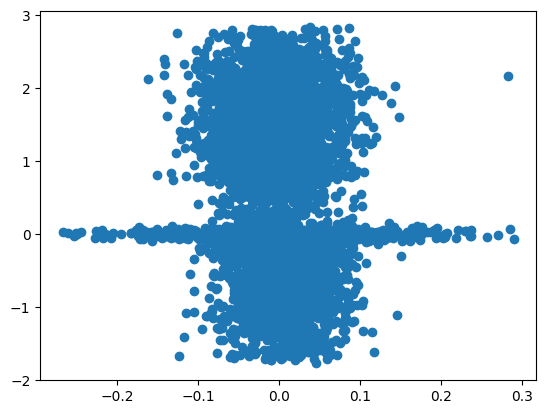

In [20]:
plot_xy = np.array(history_param)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

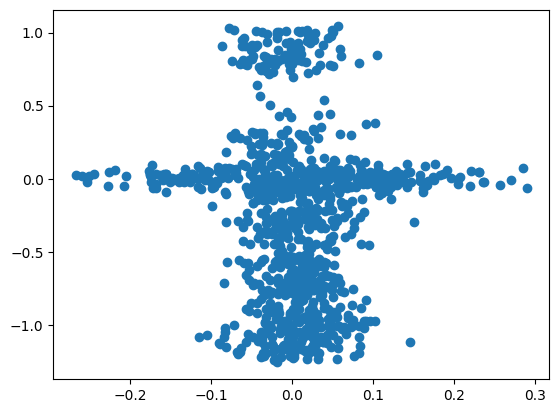

In [21]:
plot_xy = np.array(history_param)[-1000:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

In [22]:
post_params = []

In [23]:
n_post_loop = 1
while len(post_params) < n_post_samples:
    chosen_eval_inds = np.random.choice(np.arange(total_M), size=chosen_M, replace=False).tolist()
    chosen_total_inds = chosen_eval_inds + np.arange(total_M, total_M + n).tolist()

    chosen_x = total_x[chosen_total_inds]
    chosen_kernel_xx = kernel_total[chosen_total_inds,:][:,chosen_total_inds]
    # chosen_kernel_xx = np.eye(chosen_M + n)
    
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dw_logp, dU_t = fsgld_sample(est_param, train_y, train_x, chosen_x, chosen_kernel_xx, eps_t)
    
    history_param.append(est_param)
    history_logp.append(dw_logp)

    if n_post_loop % sample_cycle == 0:
        post_params.append(est_param)
    
    n_total_loop += 1
    n_post_loop += 1
    pass

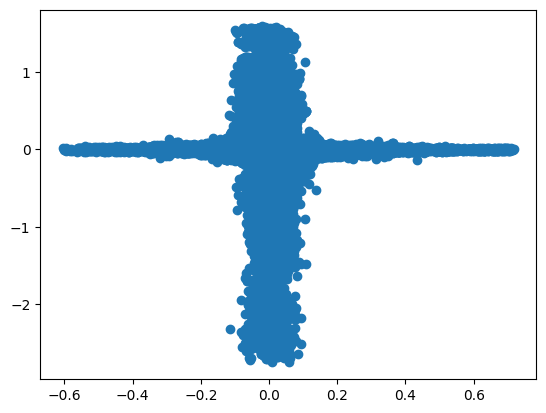

In [24]:
plot_xy = np.array(history_param)[burnin:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

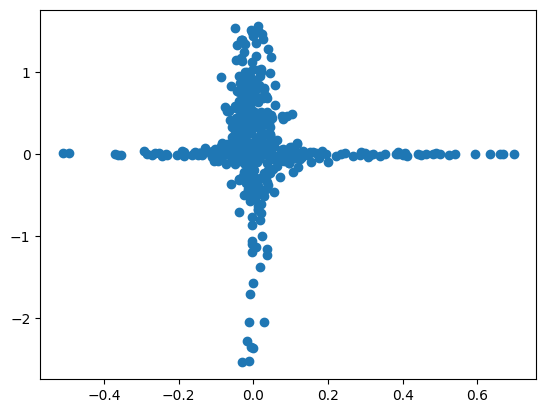

In [25]:
plot_xy = np.array(post_params)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

In [35]:
test_x = np.linspace(-5, 5, num=100)
test_y = forward(true_a, true_b, test_x)

In [36]:
post_funcs = np.array([forward(post_param[0], post_param[1], test_x) for post_param in post_params])

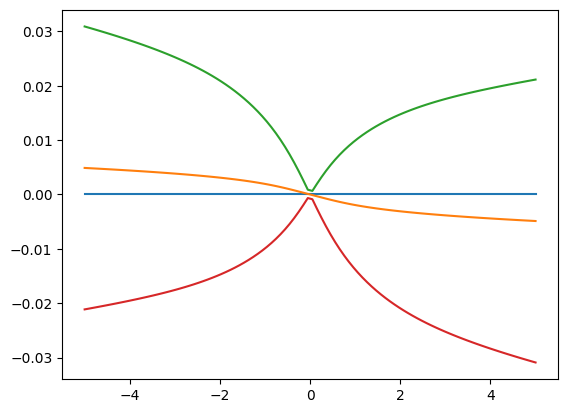

In [37]:
plt.plot(test_x, test_y)
plt.plot(test_x, post_funcs.mean(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) + post_funcs.std(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) - post_funcs.std(axis=0))
plt.show()

# Debug
+ sgld on function-space is not working, thus debug here by orginary sgld on parameter-space

In [82]:
def calc_diff_of_param(param_a: float, param_b: float, x: np.ndarray) -> np.ndarray:
    """ calc diff at x
    """
    return np.array([np.tanh(param_b*x), param_a*x/np.cosh(param_b*x)**2]).T

In [83]:
def forward(param_a: float, param_b: float, x: np.ndarray) -> np.ndarray:
    return param_a * np.tanh(param_b * x)

In [84]:
def sgld_sample(
    param: np.ndarray,
    y: np.ndarray,
    x: np.ndarray,
    pri_beta: float,
    eps_t: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """ calc for the next step of SGLD on function space
    param: tuple of a and b
    """
    param_a, param_b = param
    dw_logp = (y - forward(param_a, param_b, x)) @ calc_diff_of_param(param_a, param_b, x)
    dw_logp0 = -pri_beta * param
    dU_t = dw_logp + dw_logp0
    est_param = param + eps_t * dU_t + np.sqrt(2 * eps_t) * np.random.normal(size=dim_param)

    return est_param, dU_t, dw_logp

In [85]:
ln_seed = 20240515

In [86]:
# assume the first element is a, the second is b
dim_param = 2

In [87]:
pri_beta = 1.0

In [88]:
eps_0 = 0.001
decay_factor = 0.9
decay_cycle = 1000

In [89]:
burnin = 5000
n_post_samples = 1000
sample_cycle = 100

In [90]:
np.random.seed(ln_seed)
est_param = np.random.normal(size=dim_param)

eps_t = eps_0

history_param = []
history_logp = []
history_param.append(est_param)

In [91]:
n_total_loop = 1

In [92]:
for n_ite in range(burnin):    
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dU_t, dw_logp = sgld_sample(est_param, train_y, train_x, pri_beta, eps_t)
    history_param.append(est_param)
    history_logp.append(dw_logp)

    n_total_loop += 1
    pass

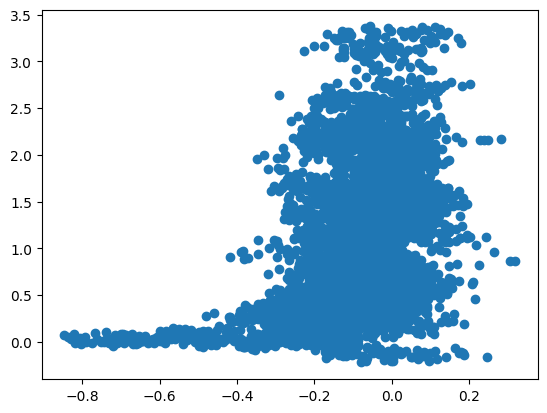

In [93]:
plot_xy = np.array(history_param)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

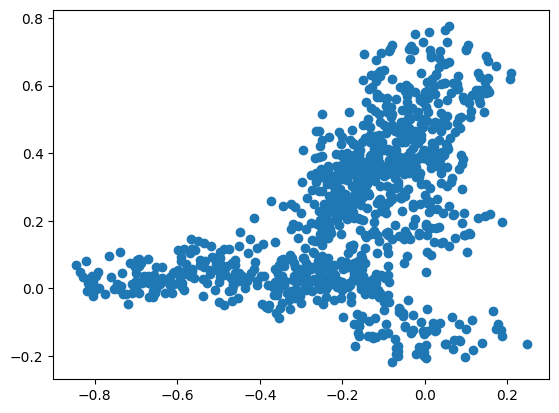

In [94]:
plot_xy = np.array(history_param)[-1000:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

In [95]:
post_params = []

In [96]:
n_post_loop = 1
while len(post_params) < n_post_samples:
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dU_t, dw_logp = sgld_sample(est_param, train_y, train_x, pri_beta, eps_t)
    
    history_param.append(est_param)
    history_logp.append(dw_logp)

    if n_post_loop % sample_cycle == 0:
        post_params.append(est_param)
    
    n_total_loop += 1
    n_post_loop += 1
    pass

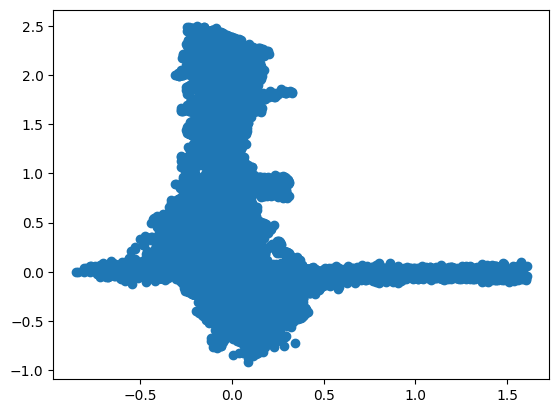

In [97]:
plot_xy = np.array(history_param)[burnin:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

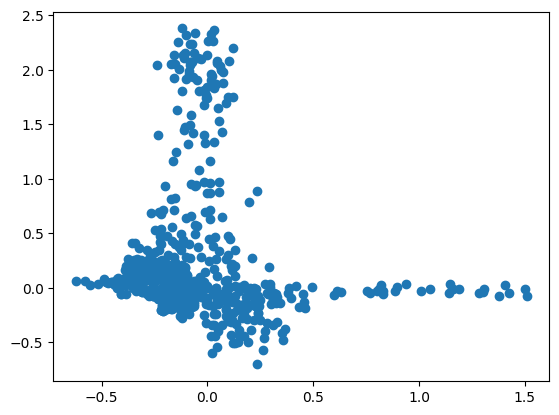

In [98]:
plot_xy = np.array(post_params)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

In [99]:
test_x = np.linspace(-5, 5, num=100)
test_y = forward(true_a, true_b, test_x)

In [100]:
post_funcs = np.array([forward(post_param[0], post_param[1], test_x) for post_param in post_params])

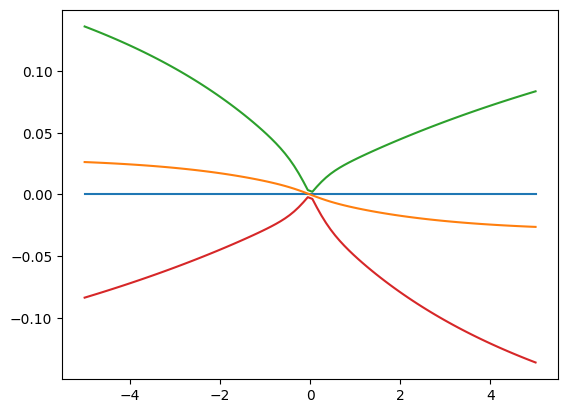

In [101]:
plt.plot(test_x, test_y)
plt.plot(test_x, post_funcs.mean(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) + post_funcs.std(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) - post_funcs.std(axis=0))
plt.show()